In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'heart.csv.csv', 'heart_disease_prediction.ipynb', 'untitled.py']


In [3]:
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Info:")
df.info()

print("\nBasic Statistics:")
display(df.describe())

FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

In [4]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\ashwi\Desktop\CodeAlpha_DiseasePrediction
['.ipynb_checkpoints', 'heart.csv.csv', 'heart_disease_prediction.ipynb', 'untitled.py']


In [5]:
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Info:")
df.info()

print("\nBasic Statistics:")
display(df.describe())

Shape: (1025, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Basic Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target value counts (0 = No Disease, 1 = Disease):
target
1    526
0    499
Name: count, dtype: int64


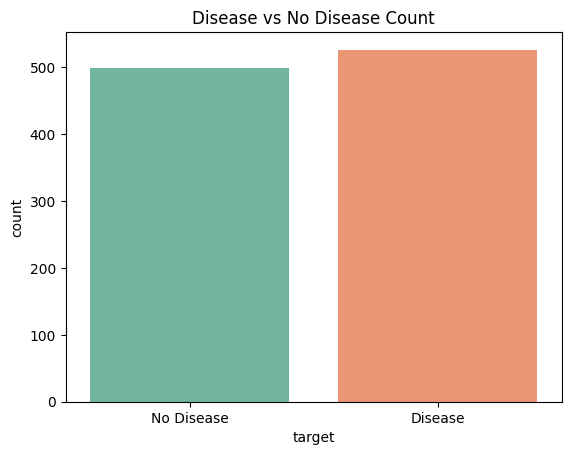

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTarget value counts (0 = No Disease, 1 = Disease):")
print(df['target'].value_counts())

sns.countplot(x='target', data=df, palette='Set2')
plt.title('Disease vs No Disease Count')
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.show()

In [7]:
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1025, 13)
Target shape: (1025,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train_scaled.shape[0]}")
print(f"Testing  samples : {X_test_scaled.shape[0]}")

Training samples : 820
Testing  samples : 205


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, max_depth=6,
                                                   min_samples_leaf=5, random_state=42),
    "XGBoost"            : XGBClassifier(max_depth=4, learning_rate=0.1,
                                          n_estimators=100, eval_metric='logloss',
                                          random_state=42)
}

trained = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained[name] = model
    print(f"✅ {name} trained!")

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!


In [15]:
results = []
for name, model in trained.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1-Score" : round(f1_score(y_test, y_pred), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
Random Forest,0.9317,0.9027,0.9714,0.9358,0.9787
XGBoost,0.8683,0.8421,0.9143,0.8767,0.9590


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, max_depth=6,
                                                   min_samples_leaf=5, random_state=42),
    "XGBoost"            : XGBClassifier(max_depth=3, learning_rate=0.05,
                                          n_estimators=50, subsample=0.8,
                                          colsample_bytree=0.8, eval_metric='logloss',
                                          random_state=42)
}

trained = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained[name] = model
    print(f"✅ {name} trained!")

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!


In [16]:
results = []
for name, model in trained.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1-Score" : round(f1_score(y_test, y_pred), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
Random Forest,0.9317,0.9027,0.9714,0.9358,0.9787
XGBoost,0.8683,0.8421,0.9143,0.8767,0.9590


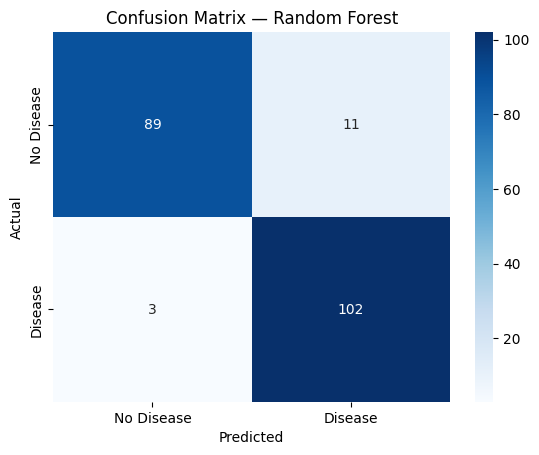


Detailed Report:
              precision    recall  f1-score   support

  No Disease       0.97      0.89      0.93       100
     Disease       0.90      0.97      0.94       105

    accuracy                           0.93       205
   macro avg       0.94      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



In [17]:
best_model = trained["Random Forest"]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nDetailed Report:")
print(classification_report(y_test, y_pred_best,
                             target_names=['No Disease','Disease']))

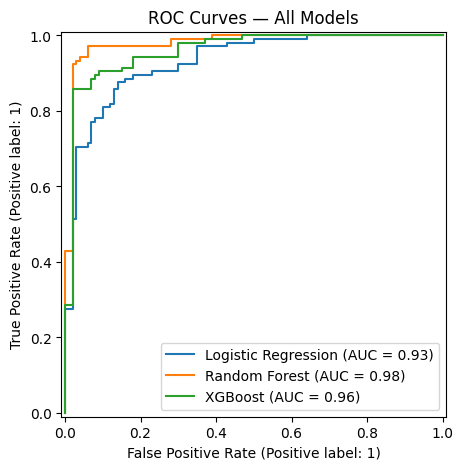

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in trained.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test,
                                   ax=ax, name=name)
ax.set_title('ROC Curves — All Models')
plt.show()

In [19]:
joblib.dump(best_model, 'heart_disease_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print("✅ Model and scaler saved!")

# Test loading and predicting
loaded_model  = joblib.load('heart_disease_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

sample_patient = pd.DataFrame([X_test.iloc[0]])
sample_scaled  = loaded_scaler.transform(sample_patient)
prediction     = loaded_model.predict(sample_scaled)
probability    = loaded_model.predict_proba(sample_scaled)[0][1]

print(f"\nPrediction : {'❤️ Heart Disease Detected' if prediction[0]==1 else '✅ No Heart Disease'}")
print(f"Confidence : {probability*100:.1f}%")

✅ Model and scaler saved!

Prediction : ✅ No Heart Disease
Confidence : 5.4%
